### Toy Transformer - Sequence Reversal

In [25]:
import math
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.attn_weights = None  # <-- store for inspection

    def forward(self, query, key, value, mask=None):

        q_len, batch_size, _ = query.size()
        k_len, _, _ = key.size()

        # query/key/value calculation - copied Attention is All You Need
        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)

        # Split heads
        Q = Q.transpose(0,1).view(batch_size, q_len, self.num_heads, self.d_k).transpose(1,2)
        K = K.transpose(0,1).view(batch_size, k_len, self.num_heads, self.d_k).transpose(1,2)
        V = V.transpose(0,1).view(batch_size, k_len, self.num_heads, self.d_k).transpose(1,2)

        # Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        # scores: (batch, heads, q_len, k_len)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attn = torch.softmax(scores, dim=-1)
        self.attn_weights = attn.detach()

        context = torch.matmul(attn, V)
        # context: (batch, heads, q_len, d_k)

        context = context.transpose(1,2).contiguous().view(batch_size, q_len, self.d_model)
        output = self.W_o(context)

        return output.transpose(0,1)

In [ ]:
import copy

# Positional encoding of input sequence (done once)
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(1))

    def forward(self, x):
        # x: (seq_len, batch, d_model)
        return x + self.pe[:x.size(0)]

class SublayerConnection(nn.Module):
    """
    Residual connection followed by layer normalization.
    """
    def __init__(self, d_model, dropout=0.0):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, sublayer):
        # Apply sublayer, dropout, residual, then norm
        return self.norm(x + self.dropout(sublayer(x)))
    
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff=512, dropout=0.0):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(self.dropout(torch.relu(self.linear1(x))))
    
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff=512, dropout=0.0):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)

        self.sublayer1 = SublayerConnection(d_model, dropout)
        self.sublayer2 = SublayerConnection(d_model, dropout)

    def forward(self, x, mask=None):
        # Self-attention sublayer
        x = self.sublayer1(x, lambda x: self.self_attn(x, x, x, mask))
        # Feed-forward sublayer
        x = self.sublayer2(x, self.feed_forward)
        return x
    
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff=512, dropout=0.0):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)

        self.sublayer1 = SublayerConnection(d_model, dropout)
        self.sublayer2 = SublayerConnection(d_model, dropout)
        self.sublayer3 = SublayerConnection(d_model, dropout)

    def forward(self, x, memory, src_mask=None, tgt_mask=None):
        # Masked self-attention (decoder)
        x = self.sublayer1(x, lambda x: self.self_attn(x, x, x, tgt_mask))
        # Encoder-decoder cross attention
        x = self.sublayer2(x, lambda x: self.cross_attn(x, memory, memory, src_mask))
        # Feed-forward
        x = self.sublayer3(x, self.feed_forward)
        return x
    
class Encoder(nn.Module):
    def __init__(self, layer, N):
        super().__init__()
        self.layers = nn.ModuleList([copy.deepcopy(layer) for _ in range(N)])
        self.norm = nn.LayerNorm(layer.self_attn.d_model)

    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)

class Decoder(nn.Module):
    def __init__(self, layer, N):
        super().__init__()
        self.layers = nn.ModuleList([copy.deepcopy(layer) for _ in range(N)])
        self.norm = nn.LayerNorm(layer.self_attn.d_model)

    def forward(self, x, memory, src_mask=None, tgt_mask=None):
        for layer in self.layers:
            x = layer(x, memory, src_mask, tgt_mask)
        return self.norm(x)
    
class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, num_heads=4, num_layers=2, d_ff=512):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        self.pos_decoder = PositionalEncoding(d_model)

        encoder_layer = EncoderLayer(d_model, num_heads, d_ff)
        decoder_layer = DecoderLayer(d_model, num_heads, d_ff)

        self.encoder = Encoder(encoder_layer, num_layers)
        self.decoder = Decoder(decoder_layer, num_layers)

        self.output_proj = nn.Linear(d_model, vocab_size)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        # src,tgt: (seq_len, batch)
        src = self.pos_encoder(self.embedding(src))
        tgt = self.pos_decoder(self.embedding(tgt))

        memory = self.encoder(src, src_mask)
        out = self.decoder(tgt, memory, src_mask, tgt_mask)

        return self.output_proj(out)
    
def subsequent_mask(size):
    mask = torch.triu(torch.ones(size, size), diagonal=1).bool()
    return ~mask  # True where attention allowed

In [ ]:
# Define task
def generate_batch(batch_size, seq_len, vocab_size):
    # tokens from 1 .. vocab_size-1
    x = torch.randint(1, vocab_size, (batch_size, seq_len))
    y, _ = torch.sort(x, dim=1)
    return x, y

In [63]:
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"

# Hyperparameters
vocab_size = 30
seq_len = 10
d_model = 128
num_heads = 4
num_layers = 2

model = Transformer(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=num_heads,
    num_layers=num_layers,
    d_ff=256
).to(device)

optimizer = optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

print("Training...")

for step in range(1000):
    src, tgt = generate_batch(batch_size=32, seq_len=seq_len, vocab_size=vocab_size)
    src = src.transpose(0,1).to(device)  # (seq_len, batch)
    tgt = tgt.transpose(0,1).to(device)

    # Teacher forcing: decoder input is target shifted right
    BOS = 0

    tgt_input = torch.full_like(tgt, BOS)
    tgt_input[:, 1:] = tgt[:, :-1]

    tgt_mask = subsequent_mask(seq_len).to(device)

    logits = model(src, tgt_input, tgt_mask=tgt_mask)

    loss = criterion(logits.reshape(-1, vocab_size), tgt.reshape(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 100 == 0:
        print(f"step {step} loss {loss.item():.4f}")

Training...
step 0 loss 3.6007
step 100 loss 2.1462
step 200 loss 0.1606
step 300 loss 0.0262
step 400 loss 0.0078
step 500 loss 0.0054
step 600 loss 0.0041
step 700 loss 0.0032
step 800 loss 0.0026
step 900 loss 0.0022


In [64]:
model.eval()

src, tgt = generate_batch(batch_size=1, seq_len=seq_len, vocab_size=vocab_size)
src = src.transpose(0,1).to(device)

# Encode once
src_emb = model.pos_encoder(model.embedding(src))
memory = model.encoder(src_emb)

ys = torch.full((seq_len, 1), BOS, dtype=torch.long).to(device)

for i in range(seq_len):
    tgt_emb = model.pos_decoder(model.embedding(ys[:i+1]))
    tgt_mask = subsequent_mask(i+1).to(device)

    out = model.decoder(tgt_emb, memory, tgt_mask=tgt_mask)
    print(out.shape)

    logits = model.output_proj(out)

    next_token = logits[-1,0].argmax()
    ys[i,0] = next_token

print("Input:    ", src.transpose(0,1).cpu().numpy())
print("Predicted:", ys.transpose(0,1).cpu().numpy())
print("Target:   ", torch.flip(src, dims=[0]).transpose(0,1).cpu().numpy())


torch.Size([1, 1, 128])
torch.Size([2, 1, 128])
torch.Size([3, 1, 128])
torch.Size([4, 1, 128])
torch.Size([5, 1, 128])
torch.Size([6, 1, 128])
torch.Size([7, 1, 128])
torch.Size([8, 1, 128])
torch.Size([9, 1, 128])
torch.Size([10, 1, 128])
Input:     [[23 14 21 29 27 13 15  5 14 21]]
Predicted: [[21 14  5  5 15 13 27 29 14 23]]
Target:    [[21 14  5 15 13 27 29 21 14 23]]


torch.Size([1, 4, 10, 10])
tensor([[0.0881, 0.1032, 0.0736, 0.0887, 0.1385, 0.0850, 0.1658, 0.0795, 0.1077,
         0.0700],
        [0.1062, 0.1366, 0.0786, 0.0812, 0.1599, 0.0612, 0.0813, 0.1388, 0.1020,
         0.0542],
        [0.1515, 0.0311, 0.1979, 0.0487, 0.1153, 0.0765, 0.1072, 0.1089, 0.0241,
         0.1388],
        [0.1173, 0.1003, 0.0634, 0.1042, 0.1800, 0.0564, 0.1208, 0.0737, 0.1118,
         0.0720],
        [0.0752, 0.0282, 0.0190, 0.0529, 0.3650, 0.0795, 0.2080, 0.1248, 0.0313,
         0.0162],
        [0.1128, 0.0441, 0.0468, 0.1041, 0.2060, 0.1513, 0.1419, 0.1336, 0.0300,
         0.0292],
        [0.0335, 0.0106, 0.0304, 0.0503, 0.1363, 0.0372, 0.5857, 0.0751, 0.0135,
         0.0275],
        [0.0454, 0.0416, 0.0397, 0.0469, 0.1431, 0.0523, 0.1025, 0.4778, 0.0283,
         0.0225],
        [0.1088, 0.1180, 0.0657, 0.0519, 0.1232, 0.0548, 0.0595, 0.0945, 0.2163,
         0.1072],
        [0.1833, 0.0262, 0.1591, 0.0344, 0.0931, 0.0623, 0.0662, 0.0621, 0.0488,
 

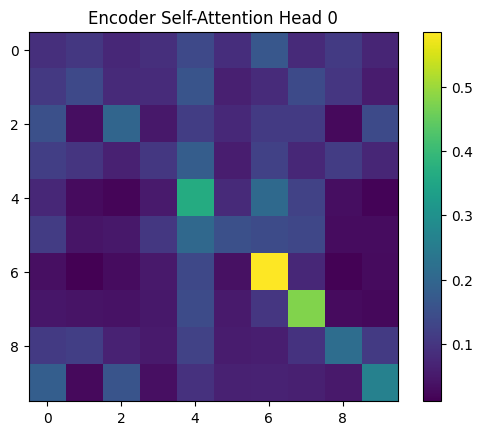

In [65]:
attn = model.encoder.layers[0].self_attn.attn_weights
print(attn.shape)
# (batch, heads, seq_len, seq_len)

print(attn[0,0])  # first batch element, first head

cross_attn = model.decoder.layers[0].cross_attn.attn_weights
print(cross_attn[0,0])

import matplotlib.pyplot as plt

plt.imshow(attn[0,0].cpu(), cmap="viridis")
plt.colorbar()
plt.title("Encoder Self-Attention Head 0")
plt.show()
